In [1]:
import numpy as np
import matplotlib.pyplot as plt


def rosenbrock(w):
    x, y = w[0], w[1]
    return (1 - x)**2 + 100 * (y - x**2)**2


def rosenbrock_grad(w):
    x, y = w[0], w[1]
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

In [2]:
def gd_backtracking_armijo(start_point, iterations=1000, c=1e-4, rho=0.5):
    w = np.array(start_point, dtype=float)
    path = [w.copy()]
    costs = [rosenbrock(w)]

    for i in range(iterations):
        grad = rosenbrock_grad(w)
        norm_grad_sq = np.dot(grad, grad)

        if np.sqrt(norm_grad_sq) < 1e-6:
            break

        alpha = 1.0
        while True:
            w_new = w - alpha * grad
            f_curr = rosenbrock(w)
            f_new = rosenbrock(w_new)

            if f_new <= f_curr - c * alpha * norm_grad_sq:
                break
            alpha *= rho

            if alpha < 1e-10:
                break

        w = w - alpha * grad
        path.append(w.copy())
        costs.append(rosenbrock(w))

    return np.array(path), costs

In [3]:
def gd_adagrad(start_point, iterations=1000, eta=0.4, epsilon=1e-8):
    w = np.array(start_point, dtype=float)
    path = [w.copy()]
    costs = [rosenbrock(w)]

    G = np.zeros_like(w)

    for i in range(iterations):
        grad = rosenbrock_grad(w)
        if np.linalg.norm(grad) < 1e-6:
            break
        G += grad**2
        adjusted_grad = (eta / (np.sqrt(G) + epsilon)) * grad
        w = w - adjusted_grad

        path.append(w.copy())
        costs.append(rosenbrock(w))

    return np.array(path), costs

Final Point (Armijo): [0.98865264 0.97736244], Cost: 0.00013, Steps: 2001
Final Point (AdaGrad): [0.95859899 0.9187515 ], Cost: 0.00172, Steps: 2001


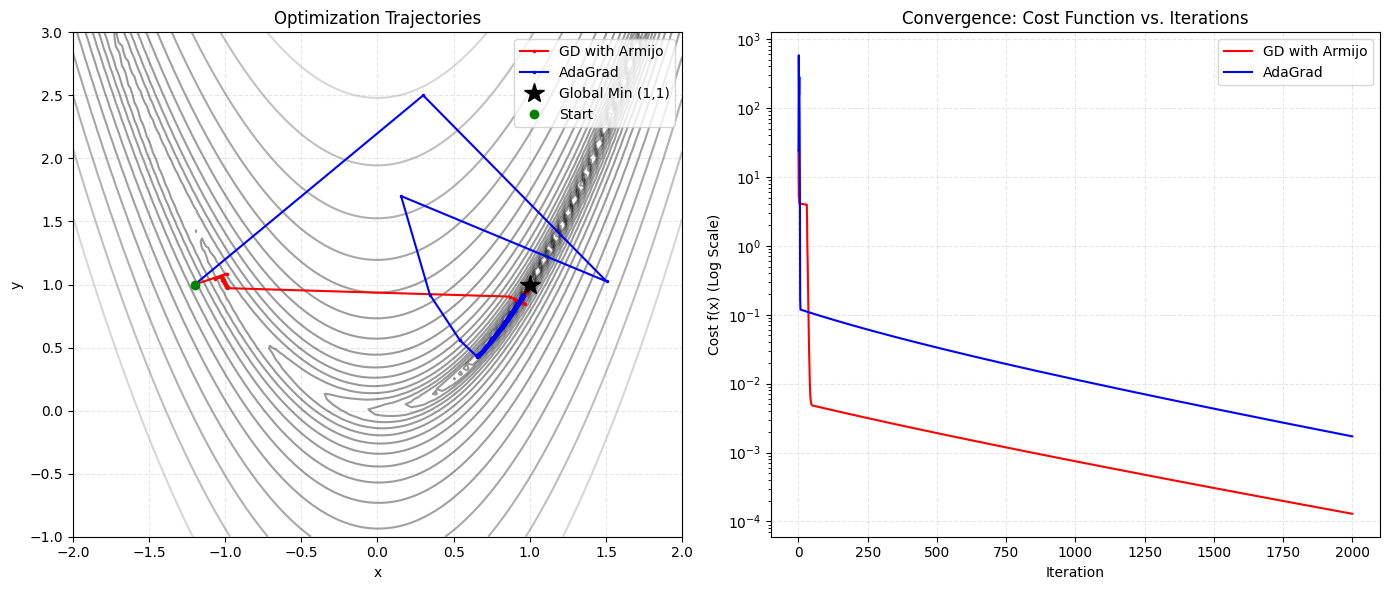

In [4]:
x0 = [-1.2, 1.0]

path_armijo, cost_armijo = gd_backtracking_armijo(x0, iterations=2000)

path_adagrad, cost_adagrad = gd_adagrad(x0, iterations=2000, eta=1.5)

print(
    f"Final Point (Armijo): {path_armijo[-1]}, Cost: {cost_armijo[-1]:.5f}, Steps: {len(path_armijo)}")
print(
    f"Final Point (AdaGrad): {path_adagrad[-1]}, Cost: {cost_adagrad[-1]:.5f}, Steps: {len(path_adagrad)}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
x_range = np.linspace(-2, 2, 100)
y_range = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = (1 - X)**2 + 100 * (Y - X**2)**2

plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='gray', alpha=0.4)
plt.plot(path_armijo[:, 0], path_armijo[:, 1],
         'r.-', label='GD with Armijo', markersize=3)
plt.plot(path_adagrad[:, 0], path_adagrad[:, 1],
         'b.-', label='AdaGrad', markersize=3)
plt.plot(1, 1, 'k*', markersize=15, label='Global Min (1,1)')
plt.plot(x0[0], x0[1], 'go', label='Start')
plt.title('Optimization Trajectories')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(cost_armijo, 'r-', label='GD with Armijo')
plt.plot(cost_adagrad, 'b-', label='AdaGrad')
plt.yscale('log')
plt.title('Convergence: Cost Function vs. Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost f(x) (Log Scale)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()